<a href="https://colab.research.google.com/github/abeerahateeq/neurofive-ml-track/blob/main/Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No


In [4]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64


In [22]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [23]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [24]:
df.drop("customerID", axis=1, inplace=True)

In [25]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [9]:
display(df.head())

,SeniorCitizen,tenure,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes
0,0,1,False,True,False,False,True,False,False,False,False,False
1,0,34,True,False,False,True,False,False,False,False,False,True
2,0,2,True,False,False,True,False,False,False,False,False,True
3,0,45,True,False,False,False,True,False,False,False,False,True
4,0,2,False,False,False,True,False,False,True,False,False,False


In [26]:
X = df.drop("Churn_Yes", axis=1)

In [27]:
y = df["Churn_Yes"]

In [28]:
print("Features (X) head:")
display(X.head())

Features (X) head:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [29]:
print("\nTarget variable (y) head:")
display(y.head())


Target variable (y) head:


,Churn_Yes
0,False
1,False
2,True
3,False
4,True


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
from xgboost import XGBClassifier

In [40]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [41]:
lr_pred = lr.predict(X_test)

In [42]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.8219


In [44]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [45]:
dt_pred = dt.predict(X_test)

In [46]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(f"Decision Tree Classifier Accuracy: {dt_accuracy:.4f}")

Decision Tree Classifier Accuracy: 0.7097


In [48]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
rf_pred = rf.predict(X_test)

In [50]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Random Forest Classifier Accuracy: {rf_accuracy:.4f}")

Random Forest Classifier Accuracy: 0.7892


In [52]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
xgb_pred = xgb.predict(X_test)

In [54]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(f"XGBoost Classifier Accuracy: {xgb_accuracy:.4f}")

XGBoost Classifier Accuracy: 0.7942


In [55]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

display(comparison.sort_values(by="Accuracy", ascending=False))

,Model,Accuracy
0,Logistic Regression,0.821859
3,XGBoost,0.794180
2,Random Forest,0.789212
1,Decision Tree,0.709723


In [10]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes'],
      dtype='object')


In [56]:
rf_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

display(rf_importance)

,Feature,Importance
3,TotalCharges,0.189701
1,tenure,0.175710
2,MonthlyCharges,0.172418
10,InternetService_Fiber optic,0.036053
28,PaymentMethod_Electronic check,0.035302
25,Contract_Two year,0.030435
13,OnlineSecurity_Yes,0.029238
4,gender_Male,0.027423
26,PaperlessBilling_Yes,0.025295
5,Partner_Yes,0.024209


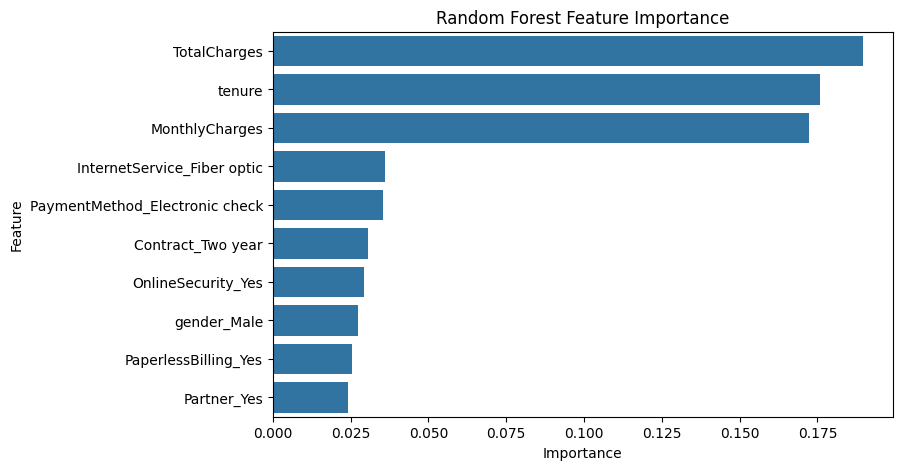

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(10)
)

plt.title("Random Forest Feature Importance")

plt.show()

In [58]:
xgb_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(xgb_importance)

,Feature,Importance
10,InternetService_Fiber optic,0.349803
25,Contract_Two year,0.216321
11,InternetService_No,0.114927
24,Contract_One year,0.065690
23,StreamingMovies_Yes,0.027371
1,tenure,0.024497
7,PhoneService_Yes,0.022461
9,MultipleLines_Yes,0.015242
28,PaymentMethod_Electronic check,0.014317
13,OnlineSecurity_Yes,0.013751


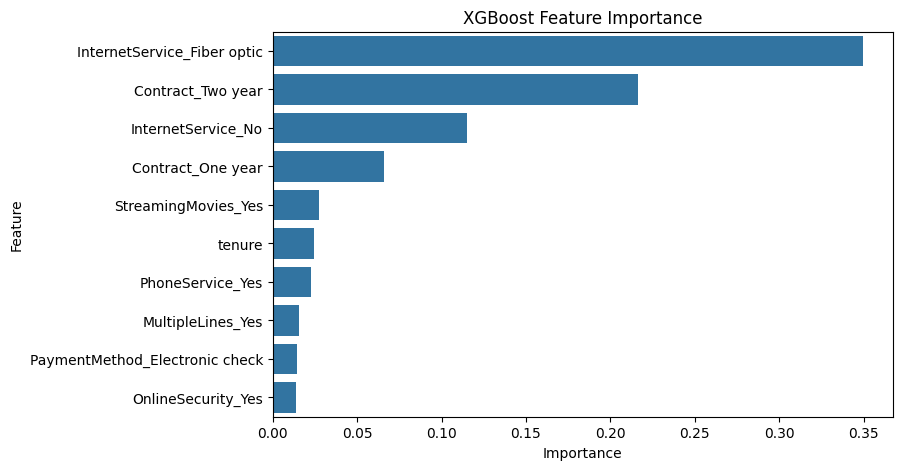

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_importance.head(10)
)

plt.title("XGBoost Feature Importance")

plt.show()

## Task 8: Ensemble Learning

## Models Compared

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

## Evaluation

Models were compared using classification accuracy.

Feature importance was analyzed for both Random Forest and XGBoost to understand which customer characteristics contributed most to churn prediction.

## Learning Outcome

This task demonstrated how ensemble methods improve predictive performance by combining multiple decision trees. Random Forest reduces variance through bagging, while XGBoost improves accuracy through boosting.

## Model Comparison

Four machine learning models were trained and evaluated on the Telco Customer Churn dataset.

| Model | Accuracy |
|--------|---------:|
| Logistic Regression | **82.19%** |
| XGBoost | **79.42%** |
| Random Forest | **78.92%** |
| Decision Tree | **70.97%** |

In this experiment, Logistic Regression achieved the highest accuracy. Although ensemble methods such as Random Forest and XGBoost are generally more powerful, their default hyperparameters may not be optimal for every dataset. This highlights the importance of model selection and hyperparameter tuning rather than assuming a more complex model will always perform better.